In [4]:
!pip -q install -U transformers datasets accelerate evaluate jiwer librosa soundfile torchaudio peft matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.7 MB/s eta 0:00:00


In [5]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [20]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/carecaller/LoRA-ft-normal')
MANIFEST = BASE_DIR / 'normal_manifest.csv'
OUTPUT_DIR = BASE_DIR / 'whisper_small_normal'
SAMPLE_RATE = 16000
MODEL_ID = 'openai/whisper-small'
LANGUAGE = 'english'
TASK = 'transcribe'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('manifest:', MANIFEST)
print('output:', OUTPUT_DIR)
if not MANIFEST.exists():
    raise FileNotFoundError(f'Manifest not found: {MANIFEST}')


manifest: /content/drive/MyDrive/carecaller/LoRA-ft-normal/normal_manifest.csv
output: /content/drive/MyDrive/carecaller/LoRA-ft-normal/whisper_small_normal


In [7]:
import os
from datasets import Audio, DatasetDict, load_dataset

BASE_DIR = '/content/drive/MyDrive/carecaller/'

# load manifest
data = load_dataset("csv", data_files={"train": os.path.join(BASE_DIR, "normal_manifest.csv")})["train"]

# drop unnecessary columns
data = data.select_columns(['audio_path', 'text'])

# fix path column
def fix_directory_path(example):
    corrected_relative_path = example['audio_path'].replace('audio/', 'normal_clips/')
    example['audio_path'] = os.path.join(BASE_DIR, corrected_relative_path)
    return example

data = data.map(fix_directory_path)

# validate fix
def file_exists(example):
    return os.path.exists(example['audio_path'])

initial_count = len(data)
data = data.filter(file_exists)
print(f"Dropped {initial_count - len(data)} missing files. Valid rows remaining: {len(data)}")

# dynamic split
split_1 = data.train_test_split(train_size=500, seed=42)
train_ds = split_1['train']
temp_ds = split_1['test']

split_2 = temp_ds.train_test_split(test_size=0.5, seed=42)
val_ds = split_2['train']
test_ds = split_2['test']

# add split column back
train_ds = train_ds.add_column('split', ['train'] * len(train_ds))
val_ds = val_ds.add_column('split', ['val'] * len(val_ds))
test_ds = test_ds.add_column('split', ['test'] * len(test_ds))

# build final dataset
ds = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds
})

ds = ds.cast_column('audio_path', Audio(sampling_rate=16000))
ds

Dropped 0 missing files. Valid rows remaining: 700


DatasetDict({
    train: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 100
    })
    test: Dataset({
        features: ['audio_path', 'text', 'split'],
        num_rows: 100
    })
})

In [8]:
# upgrade torchao package due to error
!pip install -U torchao

In [9]:
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import LoraConfig, get_peft_model

# load the base processor and model
processor = WhisperProcessor.from_pretrained(MODEL_ID, language=LANGUAGE, task=TASK)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language=LANGUAGE, task=TASK)
model.config.suppress_tokens = []
model.config.use_cache = False

# LoRA wrapper
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)
model = get_peft_model(model, lora_config)

# check for amt of paramaters trained
model.print_trainable_parameters()

# ensure we're using gpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

trainable params: 3,538,944 || all params: 245,273,856 || trainable%: 1.4429
device: cuda


In [10]:
# preps wav files for training - creates a Log-Mel Spectogram
def prepare_batch(batch):
    audio = batch['audio_path']
    batch['input_features'] = processor.feature_extractor(
        audio['array'],
        sampling_rate=audio['sampling_rate'],
    ).input_features[0]

    # tokenizer creates numerical labels for loss calculation
    batch['labels'] = processor.tokenizer(batch['text']).input_ids
    batch['input_length'] = len(audio['array']) / audio['sampling_rate']
    return batch

ds = ds.map(
    prepare_batch,
    remove_columns=ds['train'].column_names,
    num_proc=1,
)

MAX_AUDIO_SECONDS = 30.0
ds['train'] = ds['train'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)
ds['validation'] = ds['validation'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)
ds['test'] = ds['test'].filter(lambda x: x['input_length'] < MAX_AUDIO_SECONDS)

ds


DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 100
    })
    test: Dataset({
        features: ['input_features', 'labels', 'input_length'],
        num_rows: 100
    })
})

In [11]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

import torch

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:

        # pads audio tensors
        input_features = [{'input_features': feature['input_features']} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        # pads text tensors
        label_features = [{'input_ids': feature['labels']} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')


        # loss masking - only calculates loss for words, hides padding
        labels = labels_batch['input_ids'].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # slices BOS token
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch['labels'] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


In [12]:
import evaluate

wer_metric = evaluate.load('wer')
cer_metric = evaluate.load('cer')

# computes metrics - converts to percentages
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    cer = 100 * cer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': wer, 'cer': cer}


In [14]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # LoRA settings (differs from fully fine-tuned)
    learning_rate=2e-4, # more stable
    num_train_epochs=5,
    warmup_steps=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',

    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    report_to='none',
)

In [15]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['validation'],
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Wer,Cer
1,3.171324,0.606736,17.510011,10.345306
2,1.370672,0.459800,8.991627,4.777423
3,1.045936,0.398370,12.522752,7.890723
4,0.726588,0.349619,8.008737,4.319789
5,0.609123,0.317900,7.644703,4.285120


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

TrainOutput(global_step=160, training_loss=1.2518072605133057, metrics={'train_runtime': 1030.3891, 'train_samples_per_second': 2.426, 'train_steps_per_second': 0.155, 'total_flos': 7.342036992e+17, 'train_loss': 1.2518072605133057, 'epoch': 5.0})

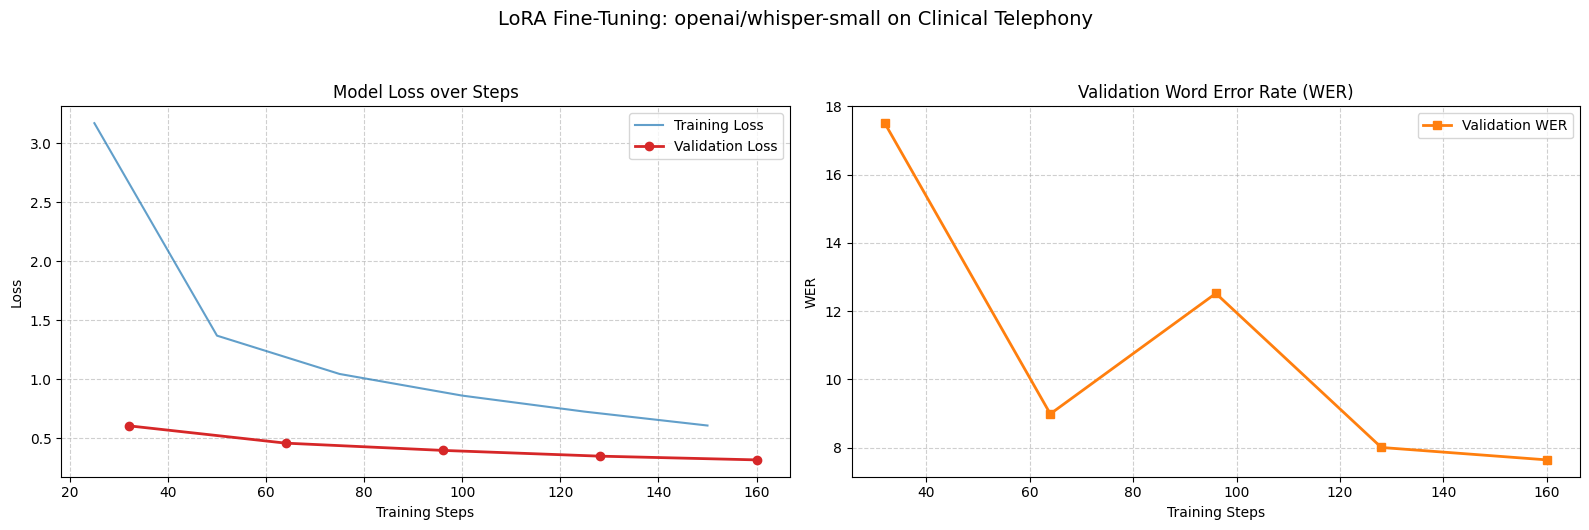

In [16]:
# Training history visualization

import matplotlib.pyplot as plt

# Pull the log history directly from the trainer memory
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []
eval_wer = []

# Parse the Hugging Face log dictionaries
for entry in log_history:
    # Training logs (happens every `logging_steps`)
    if 'loss' in entry and 'step' in entry:
        train_steps.append(entry['step'])
        train_loss.append(entry['loss'])

    # Evaluation logs (happens at the end of every epoch)
    elif 'eval_loss' in entry and 'step' in entry:
        eval_steps.append(entry['step'])
        eval_loss.append(entry['eval_loss'])
        if 'eval_wer' in entry:
            eval_wer.append(entry['eval_wer'])

# Build the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Training vs. Validation Loss ---
ax1.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', alpha=0.7)
ax1.plot(eval_steps, eval_loss, label='Validation Loss', marker='o', color='#d62728', linewidth=2)
ax1.set_title('Model Loss over Steps')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Word Error Rate (WER) ---
ax2.plot(eval_steps, eval_wer, label='Validation WER', marker='s', color='#ff7f0e', linewidth=2)
ax2.set_title('Validation Word Error Rate (WER)')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('WER')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('LoRA Fine-Tuning: openai/whisper-small on Clinical Telephony', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [17]:
# After training is done
import json

metrics = trainer.predict(ds['test']).metrics
print(metrics)

final_dir = OUTPUT_DIR / 'final'
trainer.save_model(str(final_dir))
processor.save_pretrained(str(final_dir))

with (final_dir / 'metrics.json').open('w', encoding='utf-8') as handle:
    json.dump(metrics, handle, indent=2)

{'test_loss': 0.3360036015510559, 'test_wer': 7.9178885630498534, 'test_cer': 4.35562918478636, 'test_runtime': 60.6185, 'test_samples_per_second': 1.65, 'test_steps_per_second': 0.214}


In [18]:
import librosa
import torch
import os
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from pathlib import Path

# Using relative path from root to avoid Hub validation triggers
INFER_DIR = "drive/MyDrive/carecaller/whisper_small_normal/final"
SAMPLE_AUDIO = "/content/drive/MyDrive/carecaller/sample.wav"

print(f"Loading model from local directory: {INFER_DIR}")

if not os.path.isdir(INFER_DIR):
    print(f"Error: Directory not found at {INFER_DIR}")
else:
    # Load processor and model
    processor = WhisperProcessor.from_pretrained(INFER_DIR, local_files_only=True)
    model = WhisperForConditionalGeneration.from_pretrained(INFER_DIR, local_files_only=True).to(device)

    def transcribe_file(path: str) -> str:
        audio, _ = librosa.load(path, sr=16000, mono=True)
        inputs = processor(audio, sampling_rate=16000, return_tensors='pt')
        input_features = inputs.input_features.to(device)

        predicted_ids = model.generate(input_features)
        return processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

    if Path(SAMPLE_AUDIO).exists():
        print("Transcription result:")
        print(transcribe_file(SAMPLE_AUDIO))
    else:
        print(f"File not found: {SAMPLE_AUDIO}")

Loading model from local directory: drive/MyDrive/carecaller/whisper_small_normal/final


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/144 [00:00<?, ?it/s]

Transcription result:
My child took acetaminophen at 7 PM and then ibuprofen at 8 PM, and I want to make sure that spacing was actually safe, she still has a low fever and I do not want to give the next dose too early if I wrote the schedule down wrong, I wrote the times on the box flap in a hurry, so I am worried I may have mixed up which medicine came first. If the schedule needs to be reset tonight, I would rather fix it now than keep guessing.


In [19]:
import shutil
from google.colab import files
from pathlib import Path

# Define the directory to zip and the output filename
model_path = '/content/drive/MyDrive/carecaller/whisper_small_normal/final'
zip_filename = '/content/whisper_small_LoRA_normal.zip'

if Path(model_path).exists():
    print(f'Zipping model directory: {model_path}')
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', model_path)
    print(f'Zip created at: {zip_filename}')

    print('Starting download to your computer...')
    files.download(zip_filename)
else:
    print(f'Error: Model directory not found at {model_path}. Please check if the training and saving cells finished successfully.')

Zipping model directory: /content/drive/MyDrive/carecaller/whisper_small_normal/final
Zip created at: /content/whisper_small_LoRA_normal.zip
Starting download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>